In [3]:
## tools
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from dotenv import load_dotenv
import os
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [6]:
import arxiv

api_wrapper_arxiv = ArxivAPIWrapper(top_k_results = 2, doc_content_chars_max = 500)
arxiv = ArxivQueryRun(api_wrapper = api_wrapper_arxiv, description = "Query arxiv papers")
arxiv.invoke("Attention is all you need")


"Published: 2024-07-22\nTitle: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models\nAuthors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini\nSummary: The inference demand for LLMs has skyrocketed in recent months, and serving\nmodels with low latencies remains challenging due to the quadratic input length\ncomplexity of the attention layers. In this work, we investigate the effect of\ndropping MLP and attention layers at inference time o"

In [8]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results = 1, doc_content_chars_max = 500)
wiki = WikipediaQueryRun(api_wrapper = api_wrapper_wiki)
print(wiki.name)

wikipedia


In [9]:
## Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()
tavily.invoke("Provide me the recent AI news on Nvidia.")

/var/folders/k1/5kxglv4d4pl7k44ds8wvdg0m0000gn/T/ipykernel_51425/4140560791.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


[{'title': 'Latest News - NVIDIA Newsroom',
  'url': 'http://nvidianews.nvidia.com/news/latest',
  'content': '### ‘Safety First, Always,’ NVIDIA VP of Automotive Says, Unveiling the Future of AI-Defined Vehicles at IAA Mobility\n\n### NVIDIA Unveils Rubin CPX: A New Class of GPU Designed for Massive-Context Inference\n\n### NVIDIA Blackwell Ultra Sets the Bar in New MLPerf Inference Benchmark\n\n### NVIDIA Partners With AI Infrastructure Ecosystem to Unveil Reference Design for Giga-Scale AI Factories\n\n### Get Started Using Generative AI for Content Creation With ComfyUI and NVIDIA RTX AI PCs [...] ### The AI Makers: NVIDIA Partners in UK Advance Physical and Agentic AI, Robotics, Life Sciences and More\n\n### Reaching Across the Isles: UK-LLM Brings AI to UK Languages With NVIDIA Nemotron\n\n### Paint It Blackwell: GeForce RTX 5080 SuperPOD Rollout Begins\n\n### NVIDIA Blackwell Ultra Sets New Inference Records in MLPerf Debut\n\n### NVIDIA Rubin CPX Accelerates Inference Performan

In [10]:
## Combine all these tools in the list
tools = [arxiv, wiki, tavily]

In [11]:
## Initialise the LLM model
from langchain_groq import ChatGroq
llm = ChatGroq(model = "qwen/qwen3-32b")
llm_with_tools = llm.bind_tools(tools = tools)

## Execute the call
llm_with_tools.invoke("What is the recent news on AI?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent news on AI. I need to figure out which tool to use here. Let\'s see, the available tools are arxiv, wikipedia, and tavily_search_results_json.\n\nArxiv is for academic papers, so maybe not the best choice for recent news. Wikipedia might have general information but might not be up-to-date with the latest news. The third option is tavily_search_results_json, which is described as a search engine optimized for current events. That sounds like the right tool here. \n\nI should call tavily_search_results_json with the query "recent news on AI". Let me make sure the parameters are correct. The function requires a "query" parameter, which I have. So I\'ll generate the tool call with that query.\n', 'tool_calls': [{'id': '2ecwfbr79', 'function': {'arguments': '{"query":"recent news on AI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'comple

## Workflow

In [26]:
## State Schema
from typing_extensions import TypedDict 
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, ToolMessage
from typing import Annotated ## labelling
from langgraph.graph.message import add_messages ## Reducers in LangGraph

class State(TypedDict):
    messages:list[Annotated[list[AnyMessage], add_messages]]

In [27]:
## Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state: State):
    messages = state["messages"]
    new_message = llm_with_tools.invoke(messages) # Invoke the LLM to get the new response
    
    # Append the new message to the existing list and return
    return {"messages": messages + [new_message]}


## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Build Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools _condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> toos_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")
graph = builder.compile()

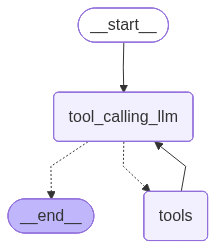

In [29]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
messages = graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})
final_messages = messages['messages']

for message in final_messages:
    message.pretty_print()

================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The latest AI news we announced in August - The Keyword", "url": "https://blog.google/technology/ai/google-ai-updates-august-2025/", "content": "# The latest AI news we announced in August\n\nSep 10, 2025\n\nHere’s a recap of some of our biggest AI updates from August, including an expansion of AI Mode in Search, the newest AI-powered Pixel devices and Google DeepMind’s “Nano Banana.”\n\nSuperG\n\n## General summary [...] From Google's labs, AI news takes flight,  \nWith updates shared for all to see the light.  \nNew search modes bloom, with agents at your call,  \nAnd Pixel's power answers every thrall.\n\nDeepMind's creations, images so grand,  \nWhile students learn, with AI close at hand.  \nNew coding tools, for tasks both big and small,  \nAnd Genie's world, where dreams can enthrall. [...] August was bananas. We had an AI Mode in Search expansion, a new